#UAS ANALISIS SINYAL DIGITAL 123
Nama  : Qoshirotu Thorfi Gibran Yusuf

NIM   : 1306622057




#Import Library

In [41]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix


#Upload Zip File


In [42]:
from google.colab import files
uploaded = files.upload()


Saving UAS.zip to UAS (1).zip


#Extract Zip file

In [43]:
import zipfile
import os

zip_name = "UAS.zip"
extract_path = "dataset_audio"

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset berhasil diekstrak")


Dataset berhasil diekstrak


#Parameter & Labeling

In [44]:
DATASET_PATH = "dataset_audio/UAS/data"
OUTPUT_PATH = "output"

GENRES = {
    "jazz": 0,
    "metal": 1
}

os.makedirs(OUTPUT_PATH, exist_ok=True)


#Ekstraksi Fitur & Simpan CSV

In [67]:
fitur_data = []
error_files = []

def amplitude_envelope(y, frame_size=1024, hop_length=512):
    """Hitung Amplitude Envelope per frame"""
    return [max(y[i:i+frame_size]) for i in range(0, len(y), hop_length)]

for genre, label in GENRES.items():
    genre_path = os.path.join(DATASET_PATH, genre)

    for file in os.listdir(genre_path):
        if file.endswith(".wav"):
            path = os.path.join(genre_path, file)

            try:
                # Load audio
                y, sr = librosa.load(path, sr=22050, mono=True)

                # Fitur dasar
                zcr = np.mean(librosa.feature.zero_crossing_rate(y))
                rms = np.mean(librosa.feature.rms(y=y))
                centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
                bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
                rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))

                # MFCC
                mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
                mfcc_mean = np.mean(mfcc, axis=1)

                # Amplitude Envelope
                amp_env = amplitude_envelope(y)
                amp_env_mean = np.mean(amp_env)   # bisa juga median atau max
                amp_env_std = np.std(amp_env)

                # Spectrogram (menggunakan magnitude)
                S = np.abs(librosa.stft(y))
                S_db = librosa.amplitude_to_db(S, ref=np.max)
                spec_mean = np.mean(S_db)
                spec_std = np.std(S_db)

                # Gabungkan semua fitur
                fitur = [
                    file, zcr, rms, centroid, bandwidth, rolloff,
                    amp_env_mean, amp_env_std,
                    spec_mean, spec_std
                ]
                fitur.extend(mfcc_mean)
                fitur.append(label)

                fitur_data.append(fitur)

            except Exception as e:
                error_files.append(file)
                print(f"⚠️ File dilewati (error): {file}")

print(f"\nTotal file error: {len(error_files)}")
print("Ekstraksi fitur selesai")

# Buat kolom DataFrame
columns = [
    "File", "ZCR", "RMS", "Centroid", "Bandwidth", "Rolloff",
    "AmpEnv_Mean", "AmpEnv_Std", "Spec_Mean", "Spec_Std"
]
columns.extend([f"MFCC_{i+1}" for i in range(13)])
columns.append("Label")


df = pd.DataFrame(fitur_data, columns=columns)

#save data ke files
csv_path = os.path.join(OUTPUT_PATH, "fitur_audio.csv")
df.to_csv(csv_path, index=False)
df.head()


/tmp/ipython-input-744232130.py:17: UserWarning:

PySoundFile failed. Trying audioread instead.

/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning:

librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.



⚠️ File dilewati (error): jazz.00054.wav

Total file error: 1
Ekstraksi fitur selesai


,File,ZCR,RMS,Centroid,Bandwidth,Rolloff,AmpEnv_Mean,AmpEnv_Std,Spec_Mean,Spec_Std,...,MFCC_5,MFCC_6,MFCC_7,MFCC_8,MFCC_9,MFCC_10,MFCC_11,MFCC_12,MFCC_13,Label
0,jazz.00078.wav,0.095869,0.119170,2503.541017,2598.597084,5155.861528,0.286524,0.152837,-57.845375,12.091888,...,1.429836,-9.165380,0.772524,0.543552,-9.180862,-2.561381,4.068378,-2.233298,-0.695601,0
1,jazz.00096.wav,0.077717,0.044384,1873.837625,2083.756432,4008.739668,0.110571,0.060061,-64.558952,13.513185,...,1.936812,22.255892,-6.142647,22.457829,-12.839392,10.778211,-7.533521,3.594645,-5.078870,0
2,jazz.00004.wav,0.047750,0.108705,1039.405743,1422.039826,1837.799766,0.244450,0.108001,-68.994804,13.250295,...,-7.959470,9.938035,-6.810833,8.250217,-6.182495,5.475854,-5.440319,-5.177866,-6.993727,0
3,jazz.00008.wav,0.046267,0.118524,1304.644766,1636.732175,2724.341557,0.304752,0.114528,-62.953094,15.065715,...,8.180399,21.443512,-4.585944,14.390953,-12.663227,10.280889,-7.942295,-1.135284,-5.053429,0
4,jazz.00072.wav,0.058721,0.110470,1336.354600,1554.563604,2751.886737,0.267027,0.140319,-66.099113,14.746193,...,-14.353488,1.644887,-7.065911,-11.128286,-4.604306,-3.609320,-3.790267,2.042838,0.847641,0


#Boxplot Feature Comparison

/tmp/ipython-input-4201171226.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




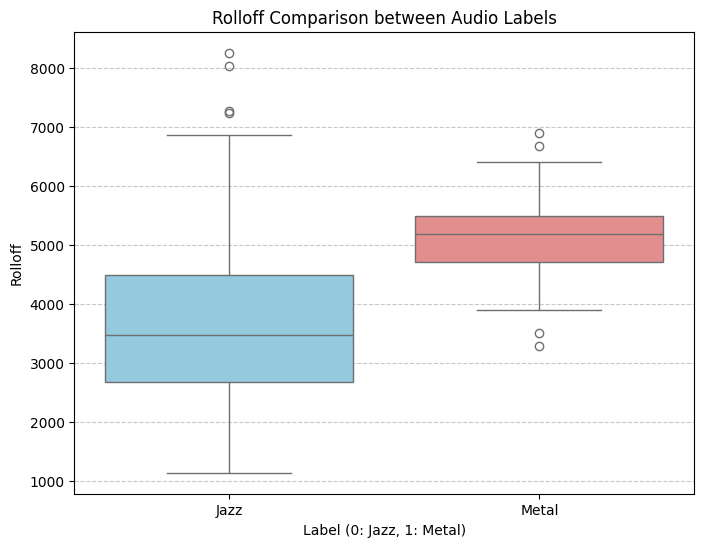

/tmp/ipython-input-4201171226.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




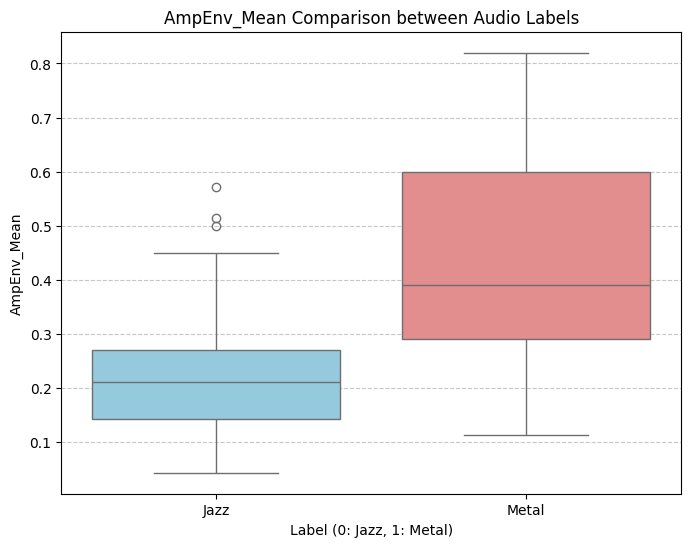

/tmp/ipython-input-4201171226.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




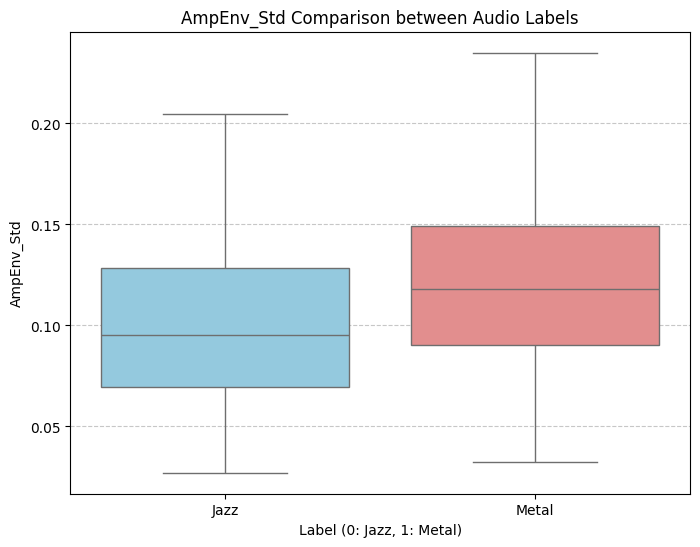

/tmp/ipython-input-4201171226.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




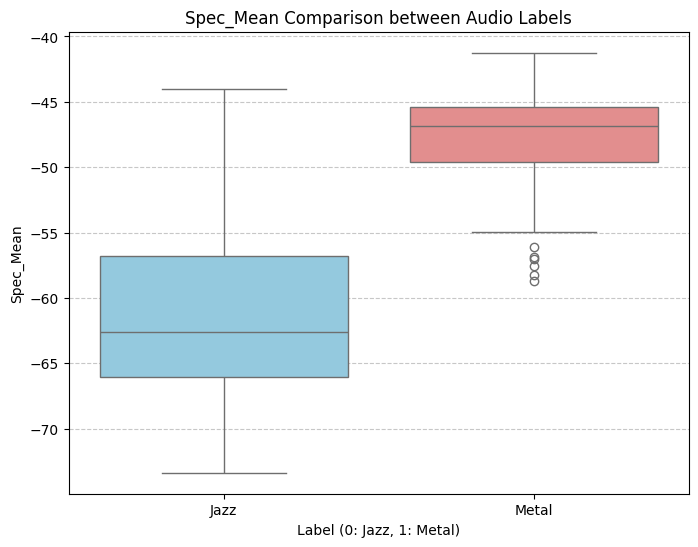

/tmp/ipython-input-4201171226.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




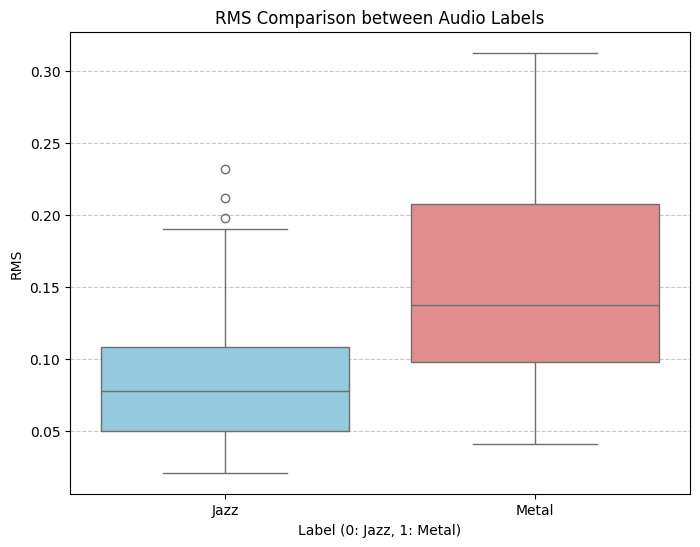

/tmp/ipython-input-4201171226.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




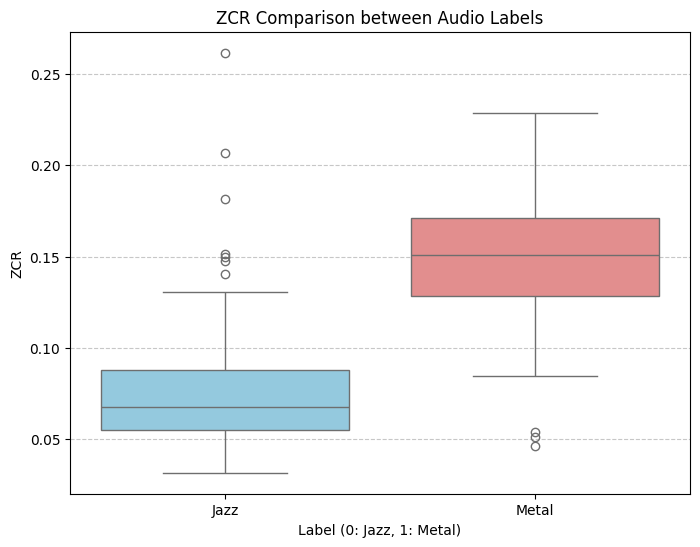

/tmp/ipython-input-4201171226.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




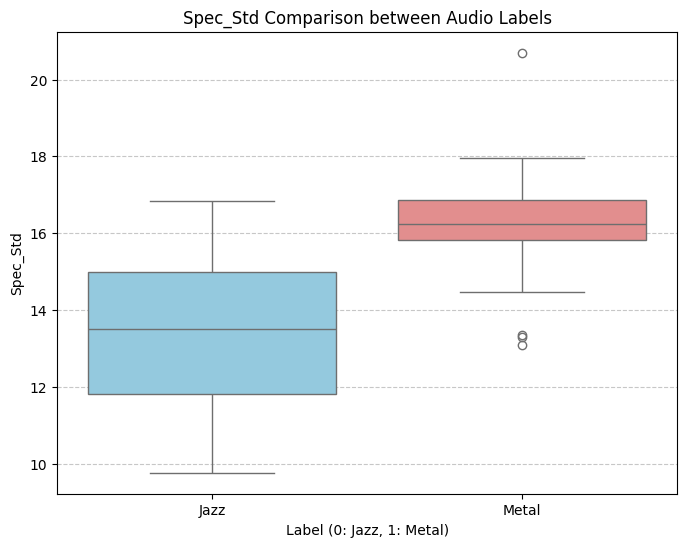

In [73]:
features_to_plot = [
    'Rolloff',
    'AmpEnv_Mean',
    'AmpEnv_Std',
    'Spec_Mean',
    'RMS',
    'ZCR',
    'Spec_Std'
]

for feature in features_to_plot:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df, x='Label', y=feature, palette={'0': 'skyblue', '1': 'lightcoral'})
    plt.title(f'{feature} Comparison between Audio Labels')
    plt.xlabel('Label (0: Jazz, 1: Metal)')
    plt.ylabel(feature)
    plt.xticks(ticks=[0, 1], labels=['Jazz', 'Metal'])
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

#Heatmap Corelation

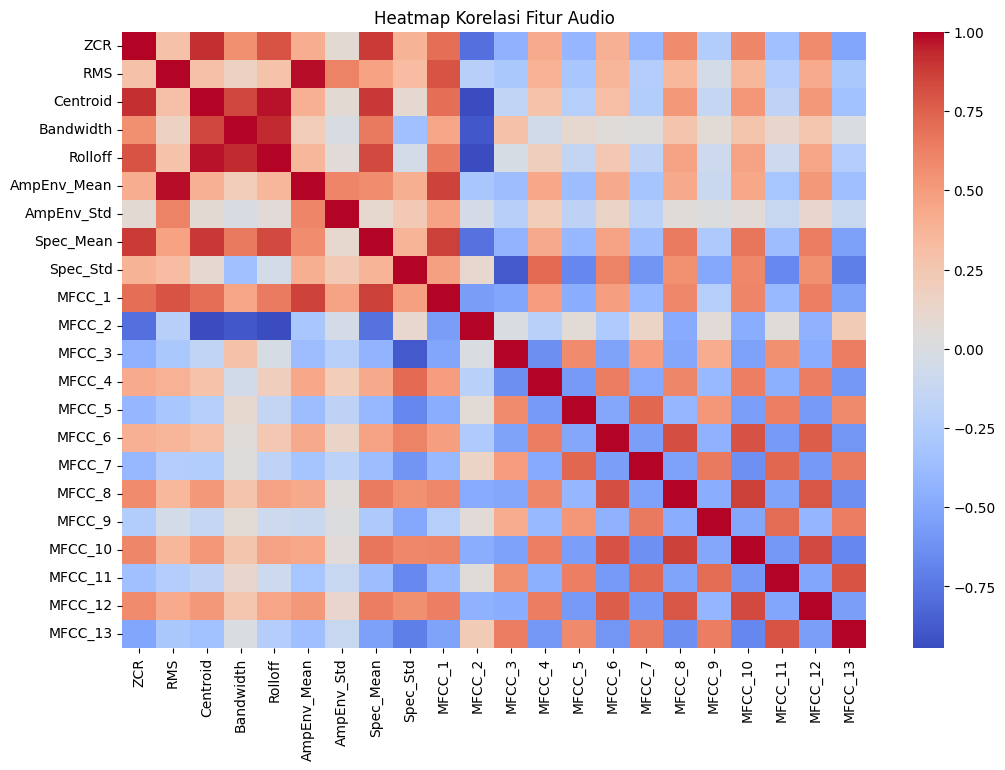

In [74]:
fitur_only = df.drop(columns=["File", "Label"])

plt.figure(figsize=(12,8))
sns.heatmap(fitur_only.corr(), cmap="coolwarm")
plt.title("Heatmap Korelasi Fitur Audio")
plt.show()


Berdasarkan heatmap korelasi fitur audio, terlihat bahwa fitur energi (RMS dan envelope amplitudo) serta fitur spektral memiliki korelasi positif yang kuat, khususnya pada musik Metal. Zero Crossing Rate juga berkorelasi positif dengan spectral centroid dan rolloff, menandakan dominasi komponen frekuensi tinggi pada musik Metal. Sebaliknya, musik Jazz menunjukkan karakteristik sinyal yang lebih variatif dengan korelasi MFCC yang tidak sekuat Metal. Hal ini menjelaskan mengapa musik Metal lebih mudah diklasifikasikan dibandingkan Jazz.

#2 axes PCA

In [75]:
scaler = StandardScaler()
fitur_scaled = scaler.fit_transform(fitur_only)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(fitur_scaled)

df["PC1"] = pca_result[:,0]
df["PC2"] = pca_result[:,1]

print("Explained Variance Ratio PCA:")
print(pca.explained_variance_ratio_)


Explained Variance Ratio PCA:
[0.47894206 0.20102128]


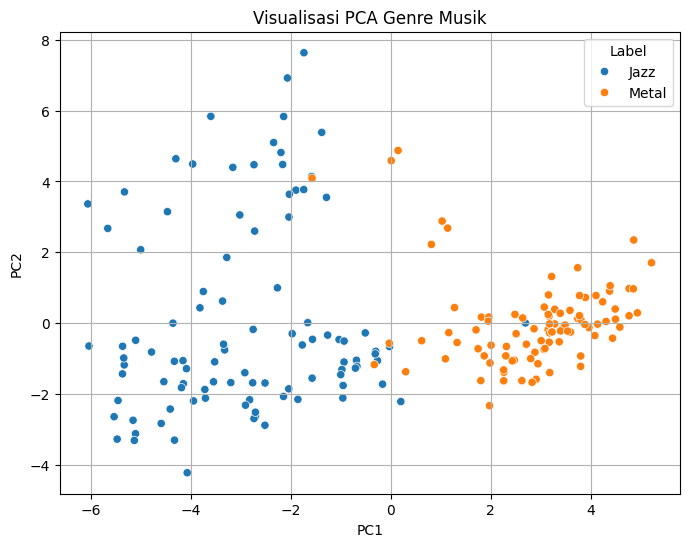

In [76]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="PC1",
    y="PC2",
    hue=df["Label"].map({0:"Jazz", 1:"Metal"})
)
plt.title("Visualisasi PCA Genre Musik")
plt.grid()
plt.show()

#3 axes PCA

In [77]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Ambil fitur numerik saja
X = df.drop(columns=["File", "Label"])

# Standarisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA 3 komponen
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Simpan ke DataFrame
df["PC1"] = X_pca[:, 0]
df["PC2"] = X_pca[:, 1]
df["PC3"] = X_pca[:, 2]

# Variansi
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance:", sum(pca.explained_variance_ratio_))


Explained Variance Ratio: [0.48069689 0.22593618 0.09395155]
Total Variance: 0.8005846097488598


In [78]:
import plotly.express as px

# Mapping label ke genre
df["Genre"] = df["Label"].map({0: "Jazz", 1: "Metal"})

fig = px.scatter_3d(
    df,
    x="PC1",
    y="PC2",
    z="PC3",
    color="Genre",
    hover_data=["File"],
    title="PCA 3D Interaktif – Klasifikasi Genre Musik",
    opacity=0.8
)

fig.update_traces(marker=dict(size=6))
fig.update_layout(
    legend_title="Genre",
    scene=dict(
        xaxis_title="PC1",
        yaxis_title="PC2",
        zaxis_title="PC3"
    )
)

fig.show()


#Clasification - SVM

In [79]:
X = fitur_scaled
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = SVC(kernel="rbf")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("=== HASIL KLASIFIKASI ===")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


=== HASIL KLASIFIKASI ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        19

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

Confusion Matrix:
[[21  0]
 [ 0 19]]


In [80]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Fitur bisa menggunakan semua fitur asli atau PCA
# Pilihan 1: Fitur asli
X = df.drop(columns=["File", "Label", "PC1", "PC2", "PC3", "Genre"])
# Pilihan 2: Fitur PCA 3D (PC1, PC2, PC3)
# X = df[["PC1", "PC2", "PC3"]]

y = df["Label"]

# Split dataset: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Jumlah data training:", len(X_train))
print("Jumlah data testing:", len(X_test))


Jumlah data training: 159
Jumlah data testing: 40


In [81]:
# Buat model SVM
model = SVC(kernel="rbf", C=1.0, gamma="scale")  # RBF kernel umum untuk audio

# Training
model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)


=== Classification Report ===
              precision    recall  f1-score   support

        Jazz       0.87      0.65      0.74        20
       Metal       0.72      0.90      0.80        20

    accuracy                           0.78        40
   macro avg       0.79      0.78      0.77        40
weighted avg       0.79      0.78      0.77        40

=== Confusion Matrix ===
[[13  7]
 [ 2 18]]


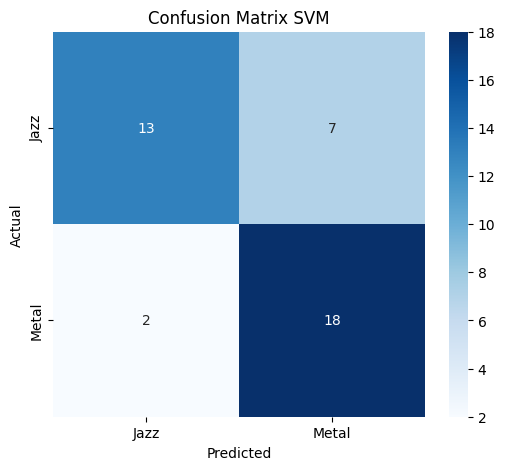

In [82]:
# Laporan klasifikasi
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=["Jazz","Metal"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("=== Confusion Matrix ===")
print(cm)

# Visualisasi Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Jazz","Metal"],
            yticklabels=["Jazz","Metal"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix SVM")
plt.show()


Dari confusion matrix:

Musik Metal:


*   18 data terklasifikasi benar

* Hanya 2 data salah diklasifikasikan sebagai Jazz. Menunjukkan bahwa ciri sinyal Metal sangat kuat dan konsisten

Musik Jazz:


*   13 data terklasifikasi benar
*   7 data salah diklasifikasikan sebagai Metal.
 Menunjukkan bahwa karakteristik Jazz lebih variatif dan sebagian tumpang tindih dengan Metal





In [83]:
from google.colab import files
files.download(csv_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Analisis
musik Jazz dan Metal dianalisis menggunakan fitur-fitur audio (misalnya RMS Energy, Zero Crossing Rate, Spectral features, dsb.) dan diklasifikasikan menggunakan Support Vector Machine (SVM).
Hasil confusion matrix menunjukkan bahwa model lebih akurat dalam mengenali musik Metal dibandingkan Jazz.





##RMS Energy
Metal:

* RMS Energy tinggi dan stabil

* Menunjukkan musik yang keras, padat, dan agresif

Jazz:

* RMS Energy lebih rendah dan fluktuatif

* Menggambarkan dinamika ekspresif, improvisasi, dan perubahan intensitas

##ZCR

Metal:

* ZCR tinggi

* Disebabkan oleh:

* Distorsi gitar

* Drum cepat

* Banyak komponen frekuensi tinggi

Jazz:

* ZCR lebih rendah

* Lebih dominan sinyal harmonik dan halus


ZCR yang tinggi membuat Metal lebih mudah dikenali oleh model.

##Karakteristik Bandwith
Metal:

* Spectral centroid lebih tinggi

* Energi tersebar di frekuensi tinggi → suara tajam & agresif

Jazz:

* Spectral centroid lebih rendah

* Dominasi instrumen akustik dan harmonik

##Mengapa Jazz Lebih Sering Salah Klasifikasi?
Beberapa lagu Jazz modern memiliki drum yang kuat, tempo cepat, dan energi tinggi

Karakteristik ini mendekati Metal secara sinyal, sehingga sebagian Jazz salah diklasifikasikan sebagai Metal oleh SVM.

Berdasarkan hasil ekstraksi fitur audio dan confusion matrix SVM, musik Metal memiliki karakteristik sinyal yang lebih konsisten dibandingkan Jazz. Fitur RMS Energy dan Zero Crossing Rate pada musik Metal cenderung lebih tinggi, mencerminkan intensitas dan kompleksitas sinyal yang besar akibat distorsi gitar dan tempo cepat. Sebaliknya, musik Jazz menunjukkan variasi energi yang lebih dinamis dan ZCR yang lebih rendah, mencerminkan struktur musik yang lebih halus dan ekspresif. Perbedaan inilah yang menyebabkan model lebih akurat dalam mengklasifikasikan musik Metal dibandingkan Jazz